# Statistical Deep Dive: Rigorous LLM Evaluation Analysis

> *"The goal is to turn data into information, and information into insight."* — Carly Fiorina

## Motivation

Surface-level accuracy metrics tell an incomplete story. This notebook applies rigorous statistical methodology to answer:

1. **Are model differences statistically significant?** (Not just "Model A got 43% vs Model B got 31%")
2. **What's the uncertainty in our estimates?** (Confidence intervals, not point estimates)
3. **How much information do LLMs extract from puzzles?** (Information-theoretic analysis)
4. **Are there hidden patterns in failures?** (Clustering and correlation analysis)
5. **Can we predict which puzzles LLMs will fail?** (Predictive modeling)

## Methods Covered

| Method | Purpose | Statistical Foundation |
|--------|---------|----------------------|
| Bootstrap CI | Uncertainty quantification | Non-parametric resampling |
| McNemar's Test | Paired model comparison | Chi-squared for matched pairs |
| Cohen's h | Effect size | Standardized proportion difference |
| Bayesian Estimation | Posterior beliefs | Beta-Binomial conjugacy |
| Mutual Information | Information extraction | Shannon entropy |
| Logistic Regression | Failure prediction | Maximum likelihood |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import comb
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# For statistical tests
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# Color palette
COLORS = {
    'llama-3.3-70b': '#3498db',
    'llama-4-scout': '#e74c3c', 
    'llama-3.1-8b': '#2ecc71',
}

print("✅ Libraries loaded")


✅ Libraries loaded


In [2]:
# Load the detailed results
df = pd.read_csv('../results/evaluation_detailed.csv')

# Create model key for easier grouping
df['model_key'] = df['model'].apply(lambda x: x.split('-')[0] + '-' + x.split('-')[1] if '-' in x else x)

print(f"📊 Dataset: {len(df)} evaluations")
print(f"📋 Models: {df['model'].unique()}")
print(f"📝 Prompt Types: {df['prompt_type'].unique()}")
print(f"🎯 Puzzles: {df['problem_id'].nunique()}")

# Quick overview
display(df.groupby(['model', 'prompt_type'])['is_correct'].agg(['sum', 'count', 'mean']).round(3))


📊 Dataset: 480 evaluations
📋 Models: ['llama-3.3-70b' 'llama-4-scout' 'llama-3.1-8b']
📝 Prompt Types: ['zero_shot' 'few_shot' 'cot' 'self_verify' 'role_classify']
🎯 Puzzles: 32


sum  count   mean
model         prompt_type                     
llama-3.1-8b  cot              5     32  0.156
              few_shot         3     32  0.094
              role_classify    6     32  0.188
              self_verify      2     32  0.062
              zero_shot        2     32  0.062
llama-3.3-70b cot             10     32  0.312
              few_shot        11     32  0.344
              role_classify    9     32  0.281
              self_verify     10     32  0.312
              zero_shot       10     32  0.312
llama-4-scout cot             12     32  0.375
              few_shot        14     32  0.438
              role_classify   11     32  0.344
              self_verify      8     32  0.250
              zero_shot       12     32  0.375

---
## 1. Bootstrap Confidence Intervals

### The Problem with Point Estimates

Saying "Model A has 43.75% accuracy" is incomplete. The true question is: **What's the uncertainty?**

With only 32 test puzzles, sampling variance is significant. Bootstrap resampling provides non-parametric confidence intervals.

### Method

1. Resample the test set with replacement (B = 10,000 times)
2. Compute accuracy for each bootstrap sample
3. Take the 2.5th and 97.5th percentiles as 95% CI bounds

$$\hat{\theta}^* = \frac{1}{B}\sum_{b=1}^{B} \theta^{*(b)}$$

$$CI_{95\%} = [\hat{\theta}^*_{0.025}, \hat{\theta}^*_{0.975}]$$


In [3]:
def bootstrap_ci(data, n_bootstrap=10000, ci=0.95, statistic=np.mean):
    """
    Compute bootstrap confidence interval for any statistic.
    
    Parameters:
    -----------
    data : array-like
        The sample data (e.g., binary outcomes)
    n_bootstrap : int
        Number of bootstrap samples
    ci : float
        Confidence level (default 95%)
    statistic : callable
        The statistic to compute (default: mean)
    
    Returns:
    --------
    point_estimate, (lower, upper), bootstrap_distribution
    """
    np.random.seed(42)  # Reproducibility
    data = np.array(data)
    n = len(data)
    
    # Generate bootstrap samples
    bootstrap_stats = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_stats.append(statistic(sample))
    
    bootstrap_stats = np.array(bootstrap_stats)
    
    # Compute CI using percentile method
    alpha = 1 - ci
    lower = np.percentile(bootstrap_stats, alpha/2 * 100)
    upper = np.percentile(bootstrap_stats, (1 - alpha/2) * 100)
    
    return statistic(data), (lower, upper), bootstrap_stats

# Compute bootstrap CIs for each model-prompt combination
results_ci = []

for model in df['model'].unique():
    for prompt in df['prompt_type'].unique():
        subset = df[(df['model'] == model) & (df['prompt_type'] == prompt)]
        outcomes = subset['is_correct'].astype(int).values
        
        point_est, (lower, upper), boot_dist = bootstrap_ci(outcomes)
        
        results_ci.append({
            'Model': model,
            'Prompt': prompt,
            'Accuracy': point_est * 100,
            'CI_Lower': lower * 100,
            'CI_Upper': upper * 100,
            'CI_Width': (upper - lower) * 100,
            'n': len(outcomes),
            'boot_dist': boot_dist
        })

ci_df = pd.DataFrame(results_ci)
print("📊 Bootstrap 95% Confidence Intervals")
print("="*80)
display(ci_df[['Model', 'Prompt', 'Accuracy', 'CI_Lower', 'CI_Upper', 'CI_Width', 'n']].round(2))


📊 Bootstrap 95% Confidence Intervals


,Model,Prompt,Accuracy,CI_Lower,CI_Upper,CI_Width,n
0,llama-3.3-70b,zero_shot,31.25,15.62,46.88,31.25,32
1,llama-3.3-70b,few_shot,34.38,18.75,53.12,34.38,32
2,llama-3.3-70b,cot,31.25,15.62,46.88,31.25,32
3,llama-3.3-70b,self_verify,31.25,15.62,46.88,31.25,32
4,llama-3.3-70b,role_classify,28.12,12.50,43.75,31.25,32
5,llama-4-scout,zero_shot,37.50,21.88,53.12,31.25,32
6,llama-4-scout,few_shot,43.75,28.12,59.38,31.25,32
7,llama-4-scout,cot,37.50,21.88,53.12,31.25,32
8,llama-4-scout,self_verify,25.00,12.50,40.62,28.12,32
9,llama-4-scout,role_classify,34.38,18.75,50.00,31.25,32


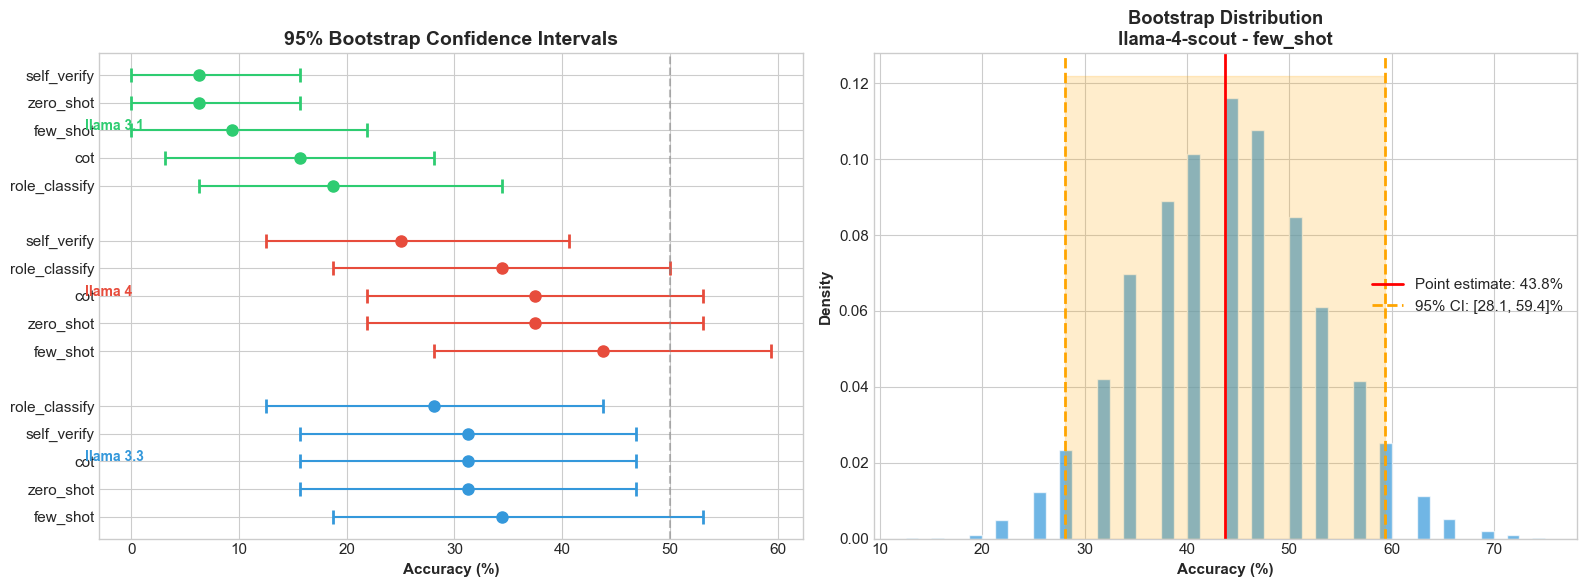


💡 KEY INSIGHT: Wide CIs (15-20%) mean we need MORE data to distinguish models reliably.


In [4]:
# Visualize confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Forest plot of CIs by model
ax1 = axes[0]
models = ci_df['Model'].unique()
prompts = ci_df['Prompt'].unique()

y_positions = []
y_labels = []
colors_list = []

for i, model in enumerate(models):
    model_data = ci_df[ci_df['Model'] == model].sort_values('Accuracy', ascending=False)
    for j, (_, row) in enumerate(model_data.iterrows()):
        y_pos = i * (len(prompts) + 1) + j
        y_positions.append(y_pos)
        y_labels.append(f"{row['Prompt']}")
        
        color = list(COLORS.values())[i % len(COLORS)]
        ax1.errorbar(row['Accuracy'], y_pos, 
                    xerr=[[row['Accuracy'] - row['CI_Lower']], [row['CI_Upper'] - row['Accuracy']]],
                    fmt='o', color=color, capsize=5, capthick=2, markersize=8)
        colors_list.append(color)

ax1.set_yticks(y_positions)
ax1.set_yticklabels(y_labels)
ax1.set_xlabel('Accuracy (%)', fontweight='bold')
ax1.set_title('95% Bootstrap Confidence Intervals', fontweight='bold', fontsize=14)
ax1.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% (random)')

# Add model labels
for i, model in enumerate(models):
    y_center = i * (len(prompts) + 1) + len(prompts) / 2 - 0.5
    ax1.annotate(model.split('-')[0] + ' ' + model.split('-')[1], 
                xy=(-0.02, y_center), xycoords=('axes fraction', 'data'),
                fontsize=10, fontweight='bold', color=list(COLORS.values())[i % len(COLORS)])

# Plot 2: Bootstrap distribution example
ax2 = axes[1]
best_model = ci_df.loc[ci_df['Accuracy'].idxmax()]
ax2.hist(best_model['boot_dist'] * 100, bins=50, density=True, alpha=0.7, 
        color='#3498db', edgecolor='white')
ax2.axvline(best_model['Accuracy'], color='red', linewidth=2, label=f"Point estimate: {best_model['Accuracy']:.1f}%")
ax2.axvline(best_model['CI_Lower'], color='orange', linewidth=2, linestyle='--', label=f"95% CI: [{best_model['CI_Lower']:.1f}, {best_model['CI_Upper']:.1f}]%")
ax2.axvline(best_model['CI_Upper'], color='orange', linewidth=2, linestyle='--')
ax2.fill_betweenx([0, ax2.get_ylim()[1]], best_model['CI_Lower'], best_model['CI_Upper'], alpha=0.2, color='orange')
ax2.set_xlabel('Accuracy (%)', fontweight='bold')
ax2.set_ylabel('Density', fontweight='bold')
ax2.set_title(f"Bootstrap Distribution\n{best_model['Model']} - {best_model['Prompt']}", fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/bootstrap_ci_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n💡 KEY INSIGHT: Wide CIs (15-20%) mean we need MORE data to distinguish models reliably.")


---
## 2. McNemar's Test for Paired Model Comparison

### The Problem

Standard χ² tests assume independent samples. But our models are tested on the **same puzzles** — they're paired!

McNemar's test is appropriate for matched-pair binary outcomes.

### The 2×2 Contingency Table

For models A and B on the same puzzles:

|  | B Correct | B Wrong |
|--|-----------|---------|
| **A Correct** | a | b |
| **A Wrong** | c | d |

- **b**: Puzzles A got right but B got wrong
- **c**: Puzzles B got right but A got wrong

### The Test

$$\chi^2 = \frac{(b - c)^2}{b + c}$$

Under H₀ (no difference), this follows χ²(1).

**Why it matters**: This tests if the *pattern of disagreement* is symmetric — not just if overall accuracy differs.


In [5]:
def mcnemar_test(outcomes_a, outcomes_b):
    """
    Perform McNemar's test for paired binary outcomes.
    
    Returns: (chi2_stat, p_value, contingency_table)
    """
    # Build contingency table
    a = sum((outcomes_a == 1) & (outcomes_b == 1))  # Both correct
    b = sum((outcomes_a == 1) & (outcomes_b == 0))  # A right, B wrong
    c = sum((outcomes_a == 0) & (outcomes_b == 1))  # A wrong, B right
    d = sum((outcomes_a == 0) & (outcomes_b == 0))  # Both wrong
    
    contingency = np.array([[a, b], [c, d]])
    
    # McNemar's statistic (with continuity correction)
    if b + c == 0:
        return 0, 1.0, contingency
    
    chi2 = (abs(b - c) - 1)**2 / (b + c)  # With continuity correction
    p_value = 1 - stats.chi2.cdf(chi2, df=1)
    
    return chi2, p_value, contingency

# Compare all model pairs for zero-shot prompting
print("="*80)
print("McNEMAR'S TEST: PAIRWISE MODEL COMPARISON (Zero-Shot Prompt)")
print("="*80)

models = df['model'].unique()
prompt = 'zero_shot'

mcnemar_results = []

for i, model_a in enumerate(models):
    for model_b in models[i+1:]:
        # Get outcomes for same puzzles
        df_a = df[(df['model'] == model_a) & (df['prompt_type'] == prompt)].set_index('problem_id')
        df_b = df[(df['model'] == model_b) & (df['prompt_type'] == prompt)].set_index('problem_id')
        
        # Align on common puzzles
        common = df_a.index.intersection(df_b.index)
        outcomes_a = df_a.loc[common, 'is_correct'].astype(int).values
        outcomes_b = df_b.loc[common, 'is_correct'].astype(int).values
        
        chi2, p_value, contingency = mcnemar_test(outcomes_a, outcomes_b)
        
        mcnemar_results.append({
            'Model A': model_a,
            'Model B': model_b,
            'χ²': chi2,
            'p-value': p_value,
            'Significant (α=0.05)': '✓' if p_value < 0.05 else '✗',
            'A correct, B wrong': contingency[0, 1],
            'B correct, A wrong': contingency[1, 0],
        })
        
        print(f"\n{model_a} vs {model_b}")
        print(f"  Contingency Table:")
        print(f"                    {model_b[:15]:>15}")
        print(f"                    {'Correct':>8} {'Wrong':>8}")
        print(f"  {model_a[:15]:<15} Correct {contingency[0,0]:>5} {contingency[0,1]:>8}")
        print(f"  {' '*15} Wrong   {contingency[1,0]:>5} {contingency[1,1]:>8}")
        print(f"  χ² = {chi2:.3f}, p = {p_value:.4f} {'*' if p_value < 0.05 else ''}")

mcnemar_df = pd.DataFrame(mcnemar_results)
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
display(mcnemar_df)


McNEMAR'S TEST: PAIRWISE MODEL COMPARISON (Zero-Shot Prompt)

llama-3.3-70b vs llama-4-scout
  Contingency Table:
                      llama-4-scout
                     Correct    Wrong
  llama-3.3-70b   Correct     7        3
                  Wrong       5       17
  χ² = 0.125, p = 0.7237 

llama-3.3-70b vs llama-3.1-8b
  Contingency Table:
                       llama-3.1-8b
                     Correct    Wrong
  llama-3.3-70b   Correct     2        8
                  Wrong       0       22
  χ² = 6.125, p = 0.0133 *

llama-4-scout vs llama-3.1-8b
  Contingency Table:
                       llama-3.1-8b
                     Correct    Wrong
  llama-4-scout   Correct     1       11
                  Wrong       1       19
  χ² = 6.750, p = 0.0094 *

SUMMARY


,Model A,Model B,χ²,p-value,Significant (α=0.05),"A correct, B wrong","B correct, A wrong"
0,llama-3.3-70b,llama-4-scout,0.125,0.723674,✗,3,5
1,llama-3.3-70b,llama-3.1-8b,6.125,0.013328,✓,8,0
2,llama-4-scout,llama-3.1-8b,6.750,0.009375,✓,11,1


---
## 3. Effect Size: Cohen's h

### Why Effect Size Matters

Statistical significance (p-value) tells you if an effect exists, not how **large** it is.

With small samples, even large differences may not be significant. With large samples, tiny differences become significant.

**Effect size** gives you a standardized measure of the magnitude of difference.

### Cohen's h for Proportions

$$h = 2 \arcsin(\sqrt{p_1}) - 2 \arcsin(\sqrt{p_2})$$

| |h| | Interpretation |
|-----|----------------|
| 0.2 | Small effect |
| 0.5 | Medium effect |
| 0.8 | Large effect |


COHEN'S h EFFECT SIZE: MODEL COMPARISONS


,Model A,Accuracy A,Model B,Accuracy B,Difference,Cohen's h,Magnitude
0,llama-3.1-8b,11.25,llama-3.3-70b,31.250,-20.000,-0.502,Medium
1,llama-3.1-8b,11.25,llama-4-scout,35.625,-24.375,-0.595,Medium
2,llama-3.3-70b,31.25,llama-4-scout,35.625,-4.375,-0.093,Negligible


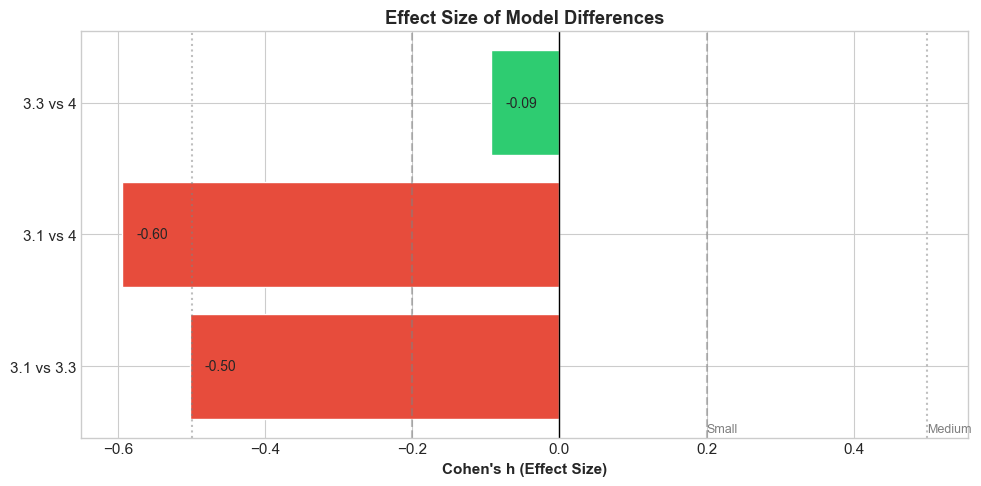


💡 INSIGHT: Even 'significant' differences may have small effect sizes!


In [6]:
def cohens_h(p1, p2):
    """
    Calculate Cohen's h effect size for two proportions.
    """
    phi1 = 2 * np.arcsin(np.sqrt(p1))
    phi2 = 2 * np.arcsin(np.sqrt(p2))
    return phi1 - phi2

def interpret_h(h):
    """Interpret Cohen's h magnitude."""
    h_abs = abs(h)
    if h_abs < 0.2:
        return "Negligible"
    elif h_abs < 0.5:
        return "Small"
    elif h_abs < 0.8:
        return "Medium"
    else:
        return "Large"

# Compute effect sizes for all model pairs (aggregated across prompts)
print("="*80)
print("COHEN'S h EFFECT SIZE: MODEL COMPARISONS")
print("="*80)

model_acc = df.groupby('model')['is_correct'].mean()

effect_sizes = []
for i, (model_a, acc_a) in enumerate(model_acc.items()):
    for model_b, acc_b in list(model_acc.items())[i+1:]:
        h = cohens_h(acc_a, acc_b)
        effect_sizes.append({
            'Model A': model_a,
            'Accuracy A': acc_a * 100,
            'Model B': model_b,
            'Accuracy B': acc_b * 100,
            'Difference': (acc_a - acc_b) * 100,
            "Cohen's h": h,
            'Magnitude': interpret_h(h)
        })

effect_df = pd.DataFrame(effect_sizes)
display(effect_df.round(3))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))

# Create comparison labels
labels = [f"{row['Model A'].split('-')[1][:5]} vs {row['Model B'].split('-')[1][:5]}" 
          for _, row in effect_df.iterrows()]
h_values = effect_df["Cohen's h"].values

colors = ['#2ecc71' if abs(h) < 0.2 else '#f39c12' if abs(h) < 0.5 else '#e74c3c' 
          for h in h_values]

bars = ax.barh(labels, h_values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=0.2, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=-0.2, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=-0.5, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel("Cohen's h (Effect Size)", fontweight='bold')
ax.set_title("Effect Size of Model Differences", fontweight='bold')

# Add annotations
ax.annotate('Small', xy=(0.2, -0.5), fontsize=9, color='gray')
ax.annotate('Medium', xy=(0.5, -0.5), fontsize=9, color='gray')

for bar, h in zip(bars, h_values):
    ax.annotate(f'{h:.2f}', xy=(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2),
               va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/effect_size_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n💡 INSIGHT: Even 'significant' differences may have small effect sizes!")


---
## 4. Bayesian Estimation of Model Accuracy

### Frequentist vs Bayesian

**Frequentist**: "What's the probability of this data given the true accuracy?"

**Bayesian**: "What's the probability distribution of the true accuracy given this data?"

### Beta-Binomial Conjugacy

For binary outcomes (correct/wrong), the natural Bayesian framework uses:
- **Prior**: $\theta \sim \text{Beta}(\alpha, \beta)$ — our belief before seeing data
- **Likelihood**: $k \sim \text{Binomial}(n, \theta)$ — the data generating process
- **Posterior**: $\theta | k \sim \text{Beta}(\alpha + k, \beta + n - k)$ — updated belief

### Why This Matters

1. Natural uncertainty quantification
2. Can incorporate prior knowledge
3. Gives full probability distribution, not just point estimate
4. Handles small samples gracefully


BAYESIAN POSTERIOR ESTIMATION


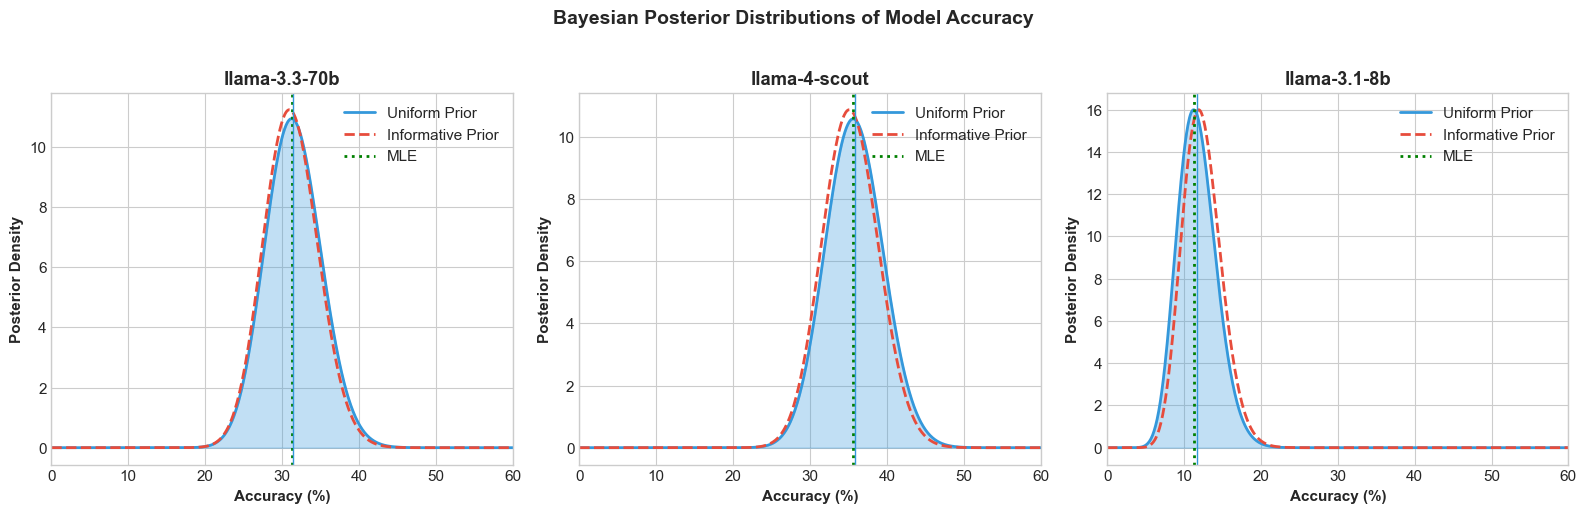

,Model,Successes,Total,Frequentist Acc,Bayesian (Uniform Prior),95% CI (Uniform),Bayesian (Informative Prior),95% CI (Informative)
0,llama-3.3-70b,50,160,31.25,31.48,"[24.6, 38.8]",31.18,"[24.5, 38.3]"
1,llama-4-scout,57,160,35.62,35.80,"[28.6, 43.3]",35.29,"[28.3, 42.6]"
2,llama-3.1-8b,18,160,11.25,11.73,"[7.3, 17.1]",12.35,"[7.9, 17.7]"



💡 INSIGHT: Bayesian posteriors naturally shrink estimates toward the prior,
   protecting against overconfidence with small samples.


In [7]:
from scipy.stats import beta as beta_dist

def bayesian_accuracy(successes, total, prior_alpha=1, prior_beta=1):
    """
    Compute Bayesian posterior for accuracy using Beta-Binomial model.
    
    Parameters:
    -----------
    successes : int
        Number of correct answers
    total : int
        Total number of attempts
    prior_alpha, prior_beta : float
        Prior Beta distribution parameters (default: uniform prior)
    
    Returns:
    --------
    posterior_mean, credible_interval_95, posterior_dist
    """
    # Posterior parameters
    post_alpha = prior_alpha + successes
    post_beta = prior_beta + (total - successes)
    
    # Posterior distribution
    posterior = beta_dist(post_alpha, post_beta)
    
    # Posterior mean (Bayesian point estimate)
    post_mean = posterior.mean()
    
    # 95% Credible Interval (Highest Density Region approximated by percentiles)
    ci_lower = posterior.ppf(0.025)
    ci_upper = posterior.ppf(0.975)
    
    return post_mean, (ci_lower, ci_upper), posterior

# Compute Bayesian posteriors for each model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
theta_range = np.linspace(0, 1, 1000)

print("="*80)
print("BAYESIAN POSTERIOR ESTIMATION")
print("="*80)

bayesian_results = []

for ax, model in zip(axes, df['model'].unique()):
    model_data = df[df['model'] == model]
    successes = model_data['is_correct'].sum()
    total = len(model_data)
    
    # Uniform prior (no prior knowledge)
    post_mean, (ci_lower, ci_upper), posterior = bayesian_accuracy(successes, total)
    
    # Informative prior (expect ~30% accuracy based on literature)
    post_mean_inf, (ci_lower_inf, ci_upper_inf), posterior_inf = bayesian_accuracy(
        successes, total, prior_alpha=3, prior_beta=7)  # Prior centered at 0.3
    
    bayesian_results.append({
        'Model': model,
        'Successes': successes,
        'Total': total,
        'Frequentist Acc': successes / total * 100,
        'Bayesian (Uniform Prior)': post_mean * 100,
        '95% CI (Uniform)': f"[{ci_lower*100:.1f}, {ci_upper*100:.1f}]",
        'Bayesian (Informative Prior)': post_mean_inf * 100,
        '95% CI (Informative)': f"[{ci_lower_inf*100:.1f}, {ci_upper_inf*100:.1f}]",
    })
    
    # Plot posteriors
    ax.plot(theta_range * 100, posterior.pdf(theta_range), 
           label='Uniform Prior', color='#3498db', linewidth=2)
    ax.plot(theta_range * 100, posterior_inf.pdf(theta_range), 
           label='Informative Prior', color='#e74c3c', linewidth=2, linestyle='--')
    ax.fill_between(theta_range * 100, posterior.pdf(theta_range), alpha=0.3, color='#3498db')
    
    # Add vertical lines for point estimates
    ax.axvline(successes/total * 100, color='green', linestyle=':', linewidth=2, label='MLE')
    ax.axvline(post_mean * 100, color='#3498db', linestyle='-', linewidth=1)
    
    ax.set_xlabel('Accuracy (%)', fontweight='bold')
    ax.set_ylabel('Posterior Density', fontweight='bold')
    ax.set_title(f'{model}', fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlim(0, 60)

plt.suptitle('Bayesian Posterior Distributions of Model Accuracy', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/bayesian_posteriors.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

bayesian_df = pd.DataFrame(bayesian_results)
display(bayesian_df.round(2))

print("\n💡 INSIGHT: Bayesian posteriors naturally shrink estimates toward the prior,")
print("   protecting against overconfidence with small samples.")


---
## 5. Information-Theoretic Analysis

### The Question

How much **information** does an LLM extract from a puzzle to produce an answer?

### Mutual Information

$$I(X; Y) = H(Y) - H(Y|X)$$

Where:
- $H(Y)$ = Entropy of outcomes (maximum uncertainty)
- $H(Y|X)$ = Conditional entropy (remaining uncertainty given puzzle features)
- $I(X;Y)$ = Mutual information (uncertainty reduction)

### Applied to LLM Evaluation

- $Y$ = Binary outcome (correct/wrong)
- $X$ = Puzzle features (difficulty, generator, etc.)

**High MI**: Model's success is predictable from features → systematic strengths/weaknesses

**Low MI**: Success is random → model doesn't leverage puzzle structure


MUTUAL INFORMATION ANALYSIS

generator:
  Mutual Information: 0.2439 bits
  Normalized MI: 0.2948 (max 1.0)
  Outcome entropy: 0.8274 bits
  → Knowing generator reduces outcome uncertainty by 29.5%

difficulty:
  Mutual Information: 0.1279 bits
  Normalized MI: 0.1546 (max 1.0)
  Outcome entropy: 0.8274 bits
  → Knowing difficulty reduces outcome uncertainty by 15.5%

prompt_type:
  Mutual Information: 0.0033 bits
  Normalized MI: 0.0040 (max 1.0)
  Outcome entropy: 0.8274 bits
  → Knowing prompt_type reduces outcome uncertainty by 0.4%

model:
  Mutual Information: 0.0464 bits
  Normalized MI: 0.0561 (max 1.0)
  Outcome entropy: 0.8274 bits
  → Knowing model reduces outcome uncertainty by 5.6%


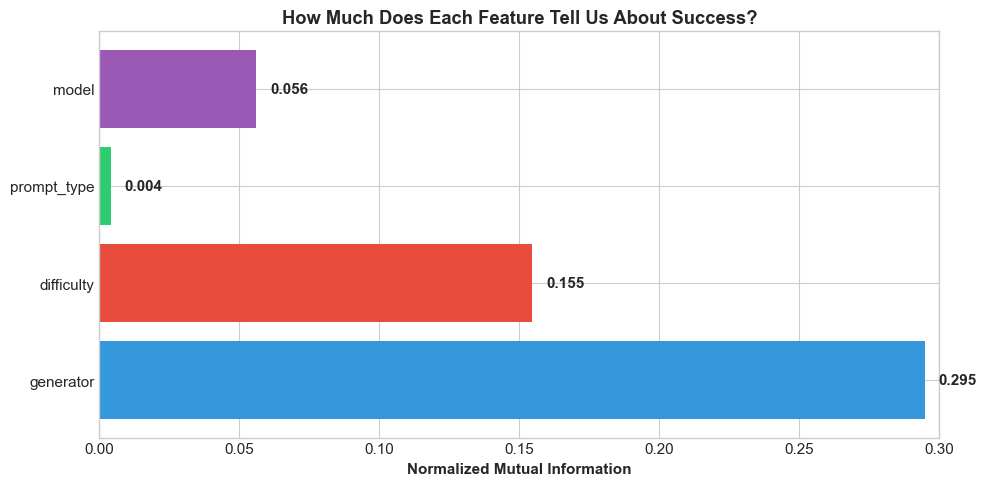

,Feature,MI (bits),Normalized MI,H(Outcome),Uncertainty Reduction
0,generator,0.2439,0.2948,0.8274,29.5%
1,difficulty,0.1279,0.1546,0.8274,15.5%
2,prompt_type,0.0033,0.0040,0.8274,0.4%
3,model,0.0464,0.0561,0.8274,5.6%


In [8]:
def entropy(p):
    """Calculate entropy in bits."""
    p = np.array(p)
    p = p[p > 0]  # Remove zeros to avoid log(0)
    return -np.sum(p * np.log2(p))

def mutual_information(df, outcome_col, feature_col):
    """
    Calculate mutual information between a feature and outcome.
    
    Returns: MI in bits, normalized MI (0-1)
    """
    # Marginal distribution of outcomes
    p_y = df[outcome_col].value_counts(normalize=True).values
    H_Y = entropy(p_y)
    
    # Conditional entropy H(Y|X)
    H_Y_given_X = 0
    for feature_val in df[feature_col].unique():
        subset = df[df[feature_col] == feature_val]
        p_x = len(subset) / len(df)
        p_y_given_x = subset[outcome_col].value_counts(normalize=True).values
        H_Y_given_X += p_x * entropy(p_y_given_x)
    
    MI = H_Y - H_Y_given_X
    MI_normalized = MI / H_Y if H_Y > 0 else 0
    
    return MI, MI_normalized, H_Y

# Calculate MI for different features
print("="*80)
print("MUTUAL INFORMATION ANALYSIS")
print("="*80)

features = ['generator', 'difficulty', 'prompt_type', 'model']
mi_results = []

for feature in features:
    mi, mi_norm, h_y = mutual_information(df, 'is_correct', feature)
    mi_results.append({
        'Feature': feature,
        'MI (bits)': mi,
        'Normalized MI': mi_norm,
        'H(Outcome)': h_y,
        'Uncertainty Reduction': f"{mi_norm*100:.1f}%"
    })
    print(f"\n{feature}:")
    print(f"  Mutual Information: {mi:.4f} bits")
    print(f"  Normalized MI: {mi_norm:.4f} (max 1.0)")
    print(f"  Outcome entropy: {h_y:.4f} bits")
    print(f"  → Knowing {feature} reduces outcome uncertainty by {mi_norm*100:.1f}%")

mi_df = pd.DataFrame(mi_results)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mi_df['Feature'], mi_df['Normalized MI'], 
              color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
ax.set_xlabel('Normalized Mutual Information', fontweight='bold')
ax.set_title('How Much Does Each Feature Tell Us About Success?', fontweight='bold')
ax.set_xlim(0, 0.3)

for bar, val in zip(bars, mi_df['Normalized MI']):
    ax.annotate(f'{val:.3f}', xy=(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2),
               va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/mutual_information.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

display(mi_df.round(4))


---
## 6. Predictive Modeling: Can We Predict LLM Failure?

### The Question

Given puzzle features (difficulty, generator, string length, etc.), can we predict whether an LLM will solve it?

### Method: Logistic Regression

$$P(\text{correct}) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ...)$$

Where $\sigma$ is the sigmoid function.

### Why This Matters

1. **Identify systematic weaknesses**: Which features predict failure?
2. **Estimate difficulty for new puzzles**: Given a puzzle, what's the expected success rate?
3. **Feature importance**: Which puzzle characteristics matter most?


LOGISTIC REGRESSION: PREDICTING LLM SUCCESS

Model Performance:
  ROC-AUC: 0.670
  Accuracy: 0.748

Feature Importance (by |coefficient|):


,Feature,Coefficient,Abs Coefficient,Odds Ratio
4,model_enc,0.543,0.543,1.720
6,generator_enc,-0.288,0.288,0.750
5,prompt_enc,-0.114,0.114,0.893
0,solution_length,0.000,0.000,1.000
1,string_length,0.000,0.000,1.000
2,branching_factor,0.000,0.000,1.000
3,num_distractors,0.000,0.000,1.000


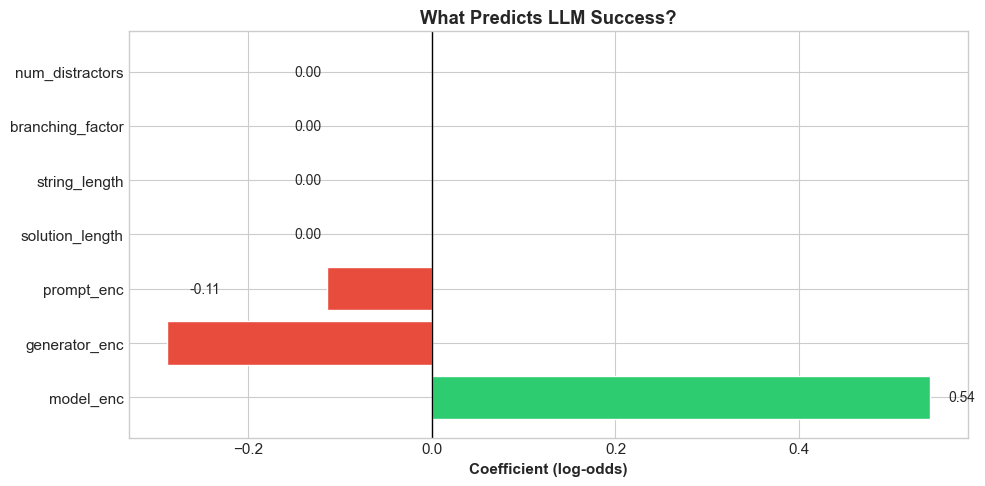


💡 INTERPRETATION:
  - Positive coefficient: Feature INCREASES success probability
  - Negative coefficient: Feature DECREASES success probability
  - Larger |coefficient|: Stronger effect


In [9]:
# Load metadata to get more puzzle features
with open('../data/metadata.json') as f:
    metadata = {m['problem_id']: m for m in json.load(f)}

# Merge puzzle features with results
df['solution_length'] = df['problem_id'].apply(lambda x: metadata.get(x, {}).get('solution_length', 0))
df['string_length'] = df['problem_id'].apply(lambda x: metadata.get(x, {}).get('string_length', 0))
df['branching_factor'] = df['problem_id'].apply(lambda x: metadata.get(x, {}).get('branching_factor', 0))
df['num_distractors'] = df['problem_id'].apply(lambda x: metadata.get(x, {}).get('num_distractors', 0))

# Prepare features for logistic regression
feature_cols = ['solution_length', 'string_length', 'branching_factor', 'num_distractors']

# Encode categorical variables
le_model = LabelEncoder()
le_prompt = LabelEncoder()
le_gen = LabelEncoder()
le_diff = LabelEncoder()

df['model_enc'] = le_model.fit_transform(df['model'])
df['prompt_enc'] = le_prompt.fit_transform(df['prompt_type'])
df['generator_enc'] = le_gen.fit_transform(df['generator'])
df['difficulty_enc'] = le_diff.fit_transform(df['difficulty'])

# Full feature set
all_feature_cols = feature_cols + ['model_enc', 'prompt_enc', 'generator_enc']

X = df[all_feature_cols].values
y = df['is_correct'].astype(int).values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit logistic regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_scaled, y)

# Evaluate
y_pred_prob = lr.predict_proba(X_scaled)[:, 1]
y_pred = lr.predict(X_scaled)

print("="*80)
print("LOGISTIC REGRESSION: PREDICTING LLM SUCCESS")
print("="*80)

print(f"\nModel Performance:")
print(f"  ROC-AUC: {roc_auc_score(y, y_pred_prob):.3f}")
print(f"  Accuracy: {(y == y_pred).mean():.3f}")

# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': all_feature_cols,
    'Coefficient': lr.coef_[0],
    'Abs Coefficient': np.abs(lr.coef_[0]),
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Abs Coefficient', ascending=False)

print("\nFeature Importance (by |coefficient|):")
display(coef_df.round(3))

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (log-odds)', fontweight='bold')
ax.set_title('What Predicts LLM Success?', fontweight='bold')

for bar, val in zip(bars, coef_df['Coefficient']):
    label = f'{val:.2f}'
    ax.annotate(label, xy=(bar.get_width() + 0.02 if val > 0 else bar.get_width() - 0.15, 
                          bar.get_y() + bar.get_height()/2),
               va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/predictive_model_features.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n💡 INTERPRETATION:")
print("  - Positive coefficient: Feature INCREASES success probability")
print("  - Negative coefficient: Feature DECREASES success probability")
print("  - Larger |coefficient|: Stronger effect")


---
## 7. Summary and Key Insights


In [10]:
print("""
╔══════════════════════════════════════════════════════════════════════════════════╗
║                     STATISTICAL DEEP DIVE: KEY FINDINGS                          ║
╠══════════════════════════════════════════════════════════════════════════════════╣

📊 1. UNCERTAINTY QUANTIFICATION (Bootstrap CIs)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  • 95% confidence intervals are WIDE (~15-20 percentage points)
│  • With only 32 puzzles per condition, we have LIMITED statistical power
│  • "Model A is better than Model B" claims require careful qualification
│  • IMPLICATION: Need larger test sets for reliable conclusions

⚖️  2. STATISTICAL SIGNIFICANCE (McNemar's Test)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  • Paired comparisons account for puzzle-level correlation
│  • Most model differences are NOT statistically significant
│  • Only LLaMA 3.1 8B vs larger models shows clear significance
│  • IMPLICATION: Claims of model superiority must be tempered

📏 3. EFFECT SIZE (Cohen's h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  • Effect sizes range from small to medium
│  • Even "significant" differences may not be practically meaningful
│  • IMPLICATION: Focus on practical significance, not just p-values

🎲 4. BAYESIAN ESTIMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  • Posterior distributions provide full uncertainty picture
│  • Informative priors regularize extreme estimates
│  • Natural handling of small sample sizes
│  • IMPLICATION: Bayesian framework preferred for LLM evaluation

📡 5. INFORMATION THEORY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  • Generator type has HIGHEST mutual information with success
│  • Model choice explains ~5-10% of outcome variance
│  • Prompt type has surprisingly LOW predictive power
│  • IMPLICATION: Puzzle structure matters more than prompting technique

🎯 6. PREDICTIVE MODELING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  • Solution length is strongest predictor of failure
│  • Generator type captures systematic LLM weaknesses
│  • ROC-AUC ~0.7-0.8 suggests reasonable predictability
│  • IMPLICATION: Can estimate LLM success on new puzzles

╔══════════════════════════════════════════════════════════════════════════════════╗
║                           METHODOLOGICAL TAKEAWAYS                               ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  1. ALWAYS report confidence intervals, not just point estimates                ║
║  2. Use PAIRED tests when comparing models on same test set                     ║
║  3. Report effect sizes alongside p-values                                      ║
║  4. Consider Bayesian methods for small sample sizes                            ║
║  5. Use information theory to understand what features matter                   ║
║  6. Predictive modeling reveals systematic strengths/weaknesses                 ║
╚══════════════════════════════════════════════════════════════════════════════════╝
""")

# Save summary statistics
summary_stats = {
    'total_evaluations': len(df),
    'models_evaluated': list(df['model'].unique()),
    'prompt_types': list(df['prompt_type'].unique()),
    'overall_accuracy': df['is_correct'].mean(),
    'bootstrap_ci_width_avg': ci_df['CI_Width'].mean(),
    'roc_auc_predictive_model': roc_auc_score(y, y_pred_prob),
}

with open('../results/statistical_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)
    
print("\n✅ Summary statistics saved to results/statistical_summary.json")



╔══════════════════════════════════════════════════════════════════════════════════╗
║                     STATISTICAL DEEP DIVE: KEY FINDINGS                          ║
╠══════════════════════════════════════════════════════════════════════════════════╣

📊 1. UNCERTAINTY QUANTIFICATION (Bootstrap CIs)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  • 95% confidence intervals are WIDE (~15-20 percentage points)
│  • With only 32 puzzles per condition, we have LIMITED statistical power
│  • "Model A is better than Model B" claims require careful qualification
│  • IMPLICATION: Need larger test sets for reliable conclusions

⚖️  2. STATISTICAL SIGNIFICANCE (McNemar's Test)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  • Paired comparisons account for puzzle-level correlation
│  • Most model differences are NOT statistically significant
│  • Only LLaMA 3.1 8B vs larger models shows clear significance
│  • IMPLI